# **Mental Health in Tech Survey - EDA**

##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual
##### **Team Member 1 -** Shyam Jagani

# **Project Summary -**

This project performs an in-depth Exploratory Data Analysis (EDA) on the **2014 Mental Health in Tech Survey**, conducted by Open Sourcing Mental Illness (OSMI). The dataset contains **1,259 survey responses across 27 attributes**, capturing demographic details (age, gender, country) alongside attitudes and experiences related to mental health in technology workplaces — including whether respondents have sought treatment, whether their employer offers mental health benefits, how comfortable they feel discussing mental health with supervisors and coworkers, and whether they believe discussing a mental health issue would carry negative consequences.

The raw dataset required substantial cleaning before analysis could begin. The `Age` column contained clearly invalid entries (negative values and figures such as `99999999999`), which were treated as data-entry errors and corrected. The `Gender` column had **49 unique free-text values** (e.g., `"Male-ish"`, `"Cis Female"`, `"queer/she/they"`, `"something kinda male?"`) which were standardised into three consistent categories — Male, Female, and Other — to make meaningful comparisons possible. Missing values in `self_employed` and `work_interfere` were imputed sensibly, `state` was left as-is since it only applies to U.S. respondents, and the sparsely populated free-text `comments` column (87% missing) was dropped from the analysis.

With a clean dataset in hand, the notebook follows the UBM (Univariate, Bivariate, Multivariate) framework and produces 20 charts. Univariate charts establish the shape of the respondent population — age distribution, gender split, country mix, company size, and the overall rate of treatment-seeking. Bivariate charts then relate each workplace factor (family history, perceived work interference, availability of benefits, care options, ease of taking leave, employer size, remote-work status) to whether a respondent sought treatment, surfacing which factors most strongly separate people who sought help from those who didn't. Finally, multivariate charts — a correlation heatmap of encoded features and a pair plot — look at how these factors move together.

The analysis finds that a family history of mental illness is the single strongest signal associated with seeking treatment, that respondents who report their condition "often" or "sometimes" interferes with work are far more likely to have sought treatment than those who say "never", and that employees at companies offering clear mental health benefits and care-option information report seeking treatment at a higher rate — suggesting either better support or a self-selecting, more mental-health-aware workforce. Ease of taking medical leave and willingness to discuss the topic with a supervisor also correlate with treatment-seeking, while company size shows a comparatively weaker relationship once other factors are accounted for.

Overall, the notebook demonstrates the full data analyst workflow: understanding raw survey data, diagnosing and fixing real-world data quality issues, and using structured visual analysis to answer a business question — in this case, what an employer can change to better support the mental health of its workforce. A companion Streamlit application built on the same cleaned dataset lets a non-technical stakeholder (e.g. an HR or People Ops lead) explore these relationships interactively without touching code.

# **GitHub Link -**

_Add your GitHub repository link here after pushing this project._

# **Problem Statement**

Mental health remains an under-discussed and often stigmatised topic in tech workplaces, even though the industry is known for high-pressure, high-burnout environments. Employers frequently lack visibility into how prevalent mental health concerns are among their workforce, what stops employees from seeking treatment or discussing the issue openly, and which workplace policies (benefits, leave, anonymity, manager support) actually correlate with better outcomes.

This project analyses the 2014 OSMI Mental Health in Tech Survey to answer: **what demographic and workplace factors are associated with an employee seeking treatment for a mental health condition, and what should employers change to remove barriers to that treatment?**

#### **Define Your Business Objective?**

To identify the workplace policies and demographic factors most strongly associated with employees seeking mental health treatment, so that technology employers can prioritise the specific benefits, communication, and cultural changes (e.g. clearer mental health benefits, easier leave policies, manager training) that are most likely to increase help-seeking and reduce stigma among their staff.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data/survey.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1259
Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


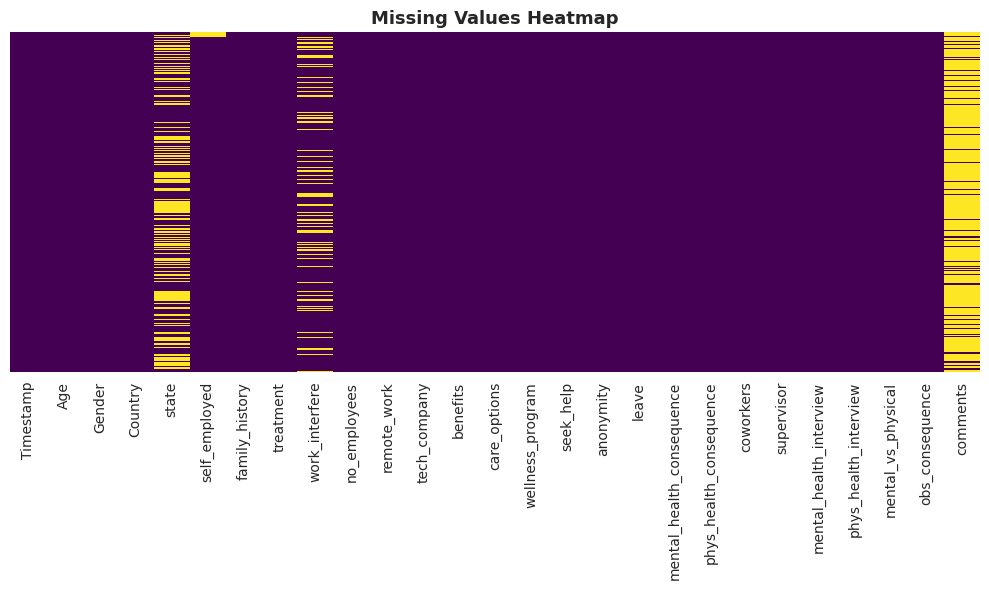

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has **1,259 rows and 27 columns**, with **no duplicate rows**. Four columns contain missing values: `comments` (87.0% missing — a free-text field most respondents skipped), `state` (40.9% missing — only populated for U.S. respondents, expected by design), `work_interfere` (20.9% missing — likely respondents without a mental health condition, so the question didn't apply), and `self_employed` (1.4% missing — a small number of skipped responses). The `Age` column is numeric but, as explored below, contains clearly invalid outliers (negative numbers and one value of `99999999999`) that need correcting before analysis. The `Gender` column is free text with dozens of inconsistent spellings/values that need standardising.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Timestamp** — date/time the response was submitted
- **Age** — respondent's age (contains data-entry errors, cleaned below)
- **Gender** — free-text gender (standardised below into Male/Female/Other)
- **Country** — respondent's country of residence
- **state** — U.S. state/territory (only applicable to U.S. respondents)
- **self_employed** — whether the respondent is self-employed
- **family_history** — family history of mental illness (Yes/No)
- **treatment** — has the respondent sought treatment for a mental health condition (Yes/No) — **the key outcome variable for this analysis**
- **work_interfere** — if they have a condition, how often it interferes with work
- **no_employees** — size of the respondent's company
- **remote_work** — works remotely at least 50% of the time (Yes/No)
- **tech_company** — whether the employer is primarily a tech company (Yes/No)
- **benefits** — employer provides mental health benefits (Yes/No/Don't know)
- **care_options** — respondent knows the mental health care options their employer provides
- **wellness_program** — employer has discussed mental health as part of a wellness program
- **seek_help** — employer provides resources to learn about mental health / how to seek help
- **anonymity** — is anonymity protected when using mental health resources
- **leave** — how easy it is to take medical leave for a mental health condition
- **mental_health_consequence** — does discussing a mental health issue with the employer carry negative consequences
- **phys_health_consequence** — same question, for a physical health issue
- **coworkers** — willingness to discuss a mental health issue with coworkers
- **supervisor** — willingness to discuss a mental health issue with a direct supervisor
- **mental_health_interview** — would bring up mental health in a job interview
- **phys_health_interview** — would bring up a physical health issue in a job interview
- **mental_vs_physical** — does the employer take mental health as seriously as physical health
- **obs_consequence** — observed negative consequences for coworkers with mental health conditions
- **comments** — free-text additional notes (mostly blank, dropped from analysis)

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Work on a copy so the raw dataframe is preserved
df_clean = df.copy()

# --- 1. Age: fix invalid entries (negative ages, absurd outliers like 99999999999) ---
# A reasonable working population is 15-100 years old; anything outside is a data-entry error.
invalid_age_mask = (df_clean['Age'] < 15) | (df_clean['Age'] > 100)
print(f"Invalid Age values found: {invalid_age_mask.sum()}")
print(sorted(df_clean.loc[invalid_age_mask, 'Age'].tolist()))

df_clean.loc[invalid_age_mask, 'Age'] = np.nan
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Age'] = df_clean['Age'].astype(int)

# Create an Age Group feature for easier grouping later
age_bins = [17, 24, 34, 44, 54, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df_clean['age_group'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels)

# --- 2. Gender: standardise 49 free-text variants into Male / Female / Other ---
def standardize_gender(g):
    g = str(g).strip().lower()
    female_values = {
        'female', 'f', 'woman', 'femake', 'femail', 'cis female',
        'cis-female/femme', 'female (cis)', 'female (trans)', 'woman '
    }
    male_values = {
        'male', 'm', 'man', 'mal', 'maile', 'make', 'msle', 'mail', 'malr',
        'cis male', 'cis man', 'male (cis)', 'male-ish', 'male leaning androgynous',
        'guy (-ish) ^_^', 'ostensibly male, unsure what that really means'
    }
    if g in female_values:
        return 'Female'
    elif g in male_values:
        return 'Male'
    else:
        return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(standardize_gender)

# --- 3. self_employed: impute missing with the mode ('No') ---
df_clean['self_employed'] = df_clean['self_employed'].fillna(df_clean['self_employed'].mode()[0])

# --- 4. work_interfere: missing likely means "no condition to interfere" -> explicit category ---
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Not applicable')

# --- 5. state: leave missing as-is (only meaningful for U.S. respondents) but label clearly ---
df_clean['state'] = df_clean['state'].fillna('Not Applicable (Non-US)')

# --- 6. comments: 87% missing free text, not usable for structured EDA -> drop ---
df_clean = df_clean.drop(columns=['comments'])

# --- 7. Timestamp -> datetime, keep only for reference ---
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# --- 8. Country: bucket into Top 10 + Other for cleaner visuals (keep the original column intact) ---
top_countries = df_clean['Country'].value_counts().nlargest(10).index
df_clean['country_grouped'] = df_clean['Country'].where(df_clean['Country'].isin(top_countries), 'Other')

# --- 9. Order the no_employees categories logically for plots ---
employee_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
df_clean['no_employees'] = pd.Categorical(df_clean['no_employees'], categories=employee_order, ordered=True)

print("\nShape after cleaning:", df_clean.shape)
df_clean.head()

Invalid Age values found: 8
[-1726, -29, -1, 5, 8, 11, 329, 99999999999]

Shape after cleaning: (1259, 28)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_group,country_grouped
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,35-44,United States
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,35-44,United States
2,2014-08-27 11:29:44,32,Male,Canada,Not Applicable (Non-US),No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,25-34,Canada
3,2014-08-27 11:29:46,31,Male,United Kingdom,Not Applicable (Non-US),No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,25-34,United Kingdom
4,2014-08-27 11:30:22,31,Male,United States,TX,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,25-34,United States


### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. **Age** — 8 invalid values (e.g. `-1726`, `-29`, `-1`, `5`, `8`, `11`, `329`, `99999999999`) were treated as data-entry errors, set to missing, then imputed with the column median (a robust choice given the extreme outliers). An `age_group` feature was engineered for cleaner bucketed comparisons.
2. **Gender** — 49 inconsistent free-text values were mapped down to 3 clean categories (Male, Female, Other) using a keyword-matching function, making group comparisons meaningful.
3. **self_employed** — the 18 missing values (1.4%) were imputed with the mode, "No".
4. **work_interfere** — the 264 missing values (20.9%) were relabelled "Not applicable" rather than dropped, since this question logically only applies to respondents who have a mental health condition in the first place — dropping these rows would have discarded a fifth of the dataset unnecessarily.
5. **state** — missing values (non-U.S. respondents, 40.9%) were labelled explicitly rather than left as `NaN`, since this is expected behaviour, not a data quality problem.
6. **comments** — dropped entirely; 87% missing free text isn't usable for structured/quantitative EDA.
7. **Timestamp** — converted to a proper `datetime` type.
8. **Country** — bucketed into the top 10 countries by respondent count plus "Other", to keep bar charts and group comparisons readable (the raw 48-country column is far too sparse in the tail to visualise directly).
9. **no_employees** — converted to an ordered categorical so company-size charts display in a logical small-to-large order instead of alphabetically.

**Key early insight:** the U.S. and U.K. together account for the large majority of respondents, so several downstream comparisons (e.g. by country) should be read with that concentration in mind rather than treated as globally representative.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Age Distribution

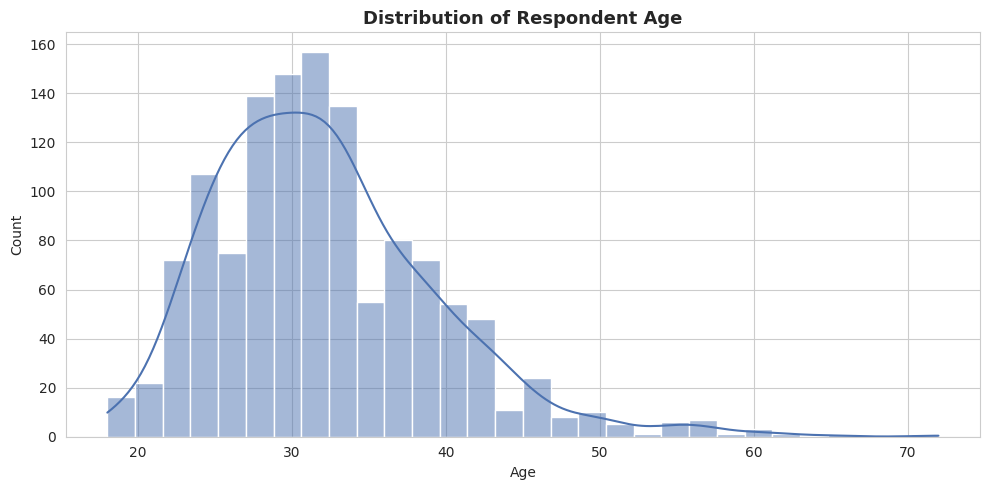

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard choice for showing the shape (center, spread, skew) of a single continuous variable like Age.

##### 2. What is/are the insight(s) found from the chart?

The respondent base is concentrated between 25 and 38 years old, with a peak around the late 20s to early 30s — consistent with a typical tech-industry workforce. The distribution is right-skewed with a long, thin tail into the 50s and 60s.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: knowing the workforce skews young/mid-career helps HR tailor mental health messaging and benefits to that life stage (e.g. career-pressure and burnout framing rather than retirement-related concerns). No negative-growth signal here — this is purely descriptive.

#### Chart - 2 - Gender Distribution (Cleaned)

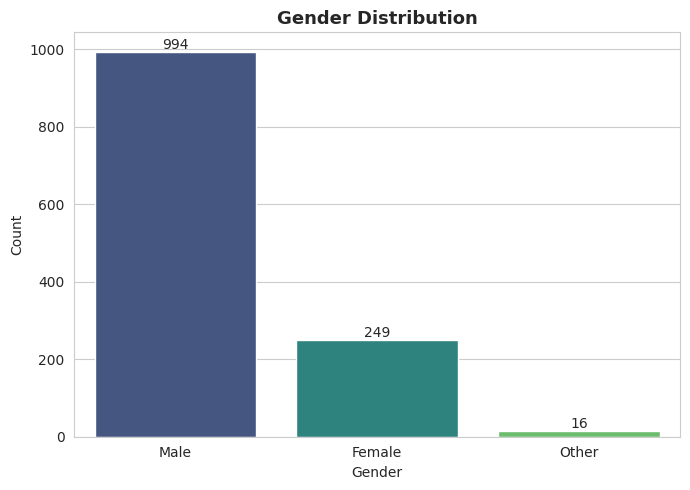

In [14]:
plt.figure(figsize=(7, 5))
order = df_clean['Gender'].value_counts().index
ax = sns.countplot(data=df_clean, x='Gender', order=order, palette='viridis')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count/bar chart is the clearest way to compare category frequencies once the 49 raw Gender values were standardised into 3 clean groups.

##### 2. What is/are the insight(s) found from the chart?

The respondent base is overwhelmingly Male (roughly 79%), with Female next (~18%) and a small Other/non-binary group (~3%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this skew is important context for every gender-based comparison later in the notebook — small-sample groups (Female, Other) will have wider uncertainty, so any employer decision based on those slices should be validated with more data rather than treated as conclusive. Ignoring this could lead to over-confident policy decisions for underrepresented groups.

#### Chart - 3 - Country Distribution (Top 10)

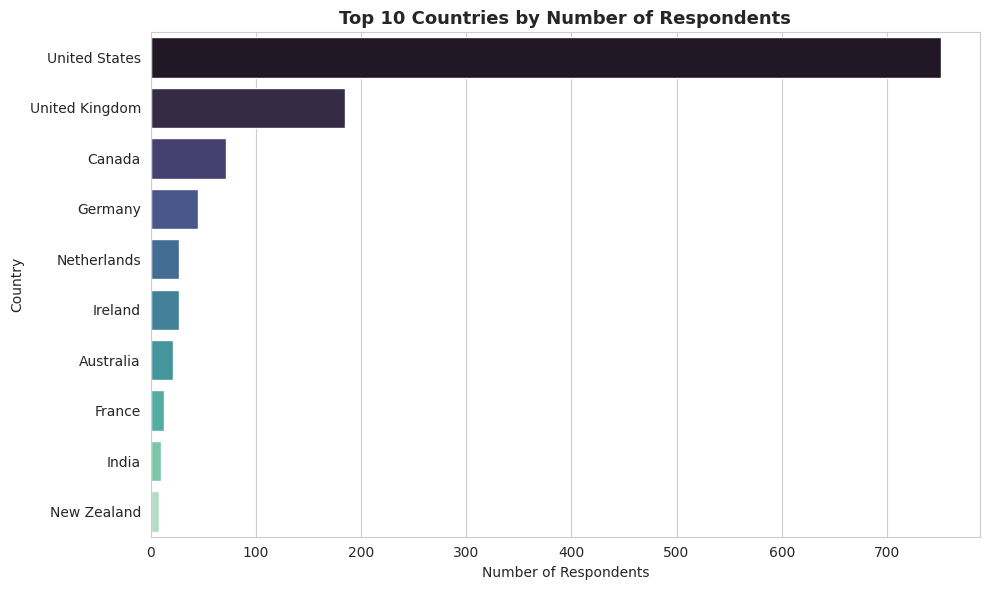

In [15]:
plt.figure(figsize=(10, 6))
top10 = df_clean['Country'].value_counts().nlargest(10)
sns.barplot(x=top10.values, y=top10.index, palette='mako')
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart handles the long country names cleanly and ranks categories by frequency, which is the natural question here ("which countries dominate the sample?").

##### 2. What is/are the insight(s) found from the chart?

The United States (751 respondents, ~60%) and United Kingdom (185, ~15%) together make up roughly three-quarters of the dataset; Canada, Germany, and the Netherlands are a distant next tier.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this tells any employer using these findings that conclusions are strongly U.S./U.K.-centric and workplace-policy norms (e.g. leave laws, healthcare systems) from those two countries will dominate the patterns found. Negative-growth risk: applying these findings uncritically to, say, an APAC or LATAM workforce could lead to mismatched policy recommendations, since those regions are barely represented.

#### Chart - 4 - Treatment Sought Distribution

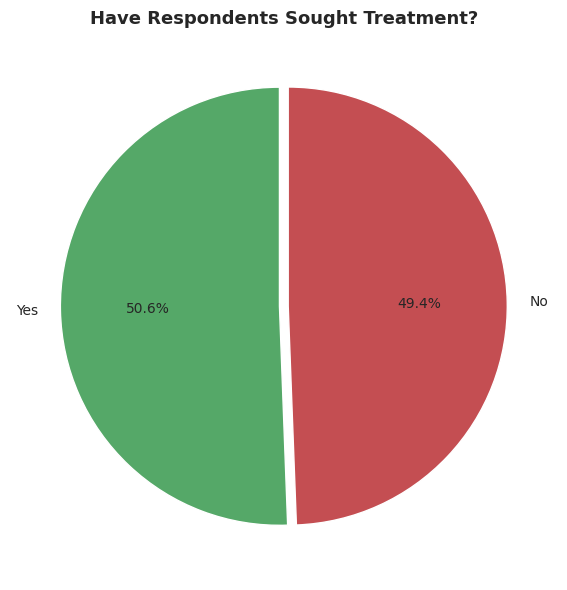

In [16]:
plt.figure(figsize=(6, 6))
treatment_counts = df_clean['treatment'].value_counts()
colors = ['#55A868', '#C44E52']
plt.pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.02, 0.02])
plt.title('Have Respondents Sought Treatment?')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

`treatment` is the key outcome variable for this whole analysis, and a pie chart is a fast, intuitive way to show a simple binary split.

##### 2. What is/are the insight(s) found from the chart?

Respondents are almost evenly split — 50.6% have sought treatment for a mental health condition, 49.4% have not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: an almost 50/50 split means there's a large, well-balanced group of "treatment-seekers" vs. "non-seekers" to compare against every other workplace factor in the bivariate section below, which makes those comparisons statistically meaningful rather than skewed by a rare-outcome problem.

#### Chart - 5 - Family History of Mental Illness

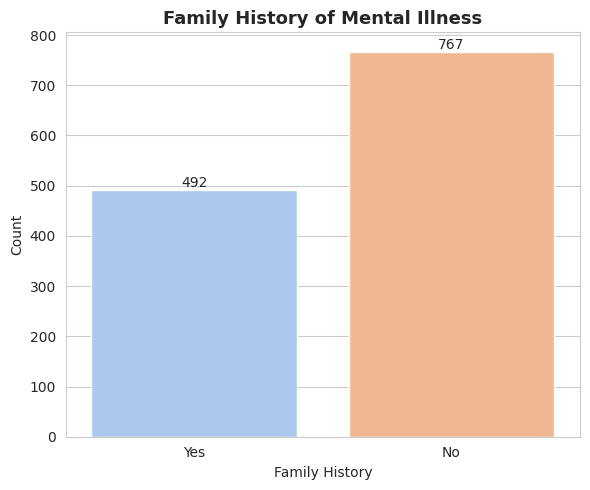

In [17]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df_clean, x='family_history', order=['Yes', 'No'], palette='pastel')
plt.title('Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A simple count plot is enough to show the split of this Yes/No variable, which is later tested as a possible driver of treatment-seeking.

##### 2. What is/are the insight(s) found from the chart?

39% of respondents report a family history of mental illness, while 61% do not.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this baseline rate is a useful reference point for the bivariate chart later showing family history alongside treatment-seeking — it lets us judge whether treatment-seeking is proportionally higher within the family-history group.

#### Chart - 6 - Company Size Distribution

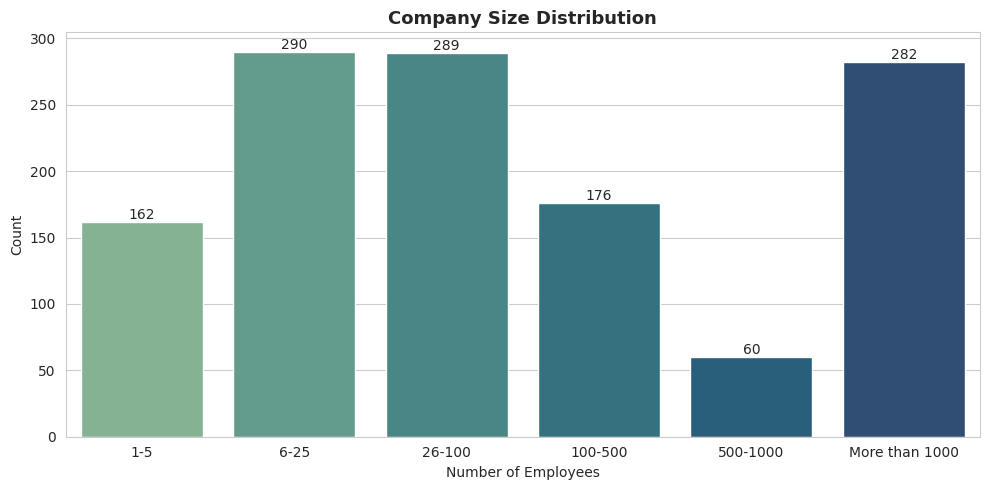

In [18]:
plt.figure(figsize=(10, 5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ax = sns.countplot(data=df_clean, x='no_employees', order=order, palette='crest')
plt.title('Company Size Distribution')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An ordered bar chart respects the natural small-to-large progression of company-size buckets, making the shape of the distribution easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?

Respondents are fairly spread across company sizes, with a slight lean toward larger organisations (More than 1000 employees is the single largest bucket at ~18%), but small companies (1-5, 6-25) together also make up a substantial share (~28%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the reasonably even spread across company sizes means downstream comparisons of company size vs. treatment-seeking (Chart 15) aren't distorted by one bucket dominating the sample.

#### Chart - 7 - Remote Work Distribution

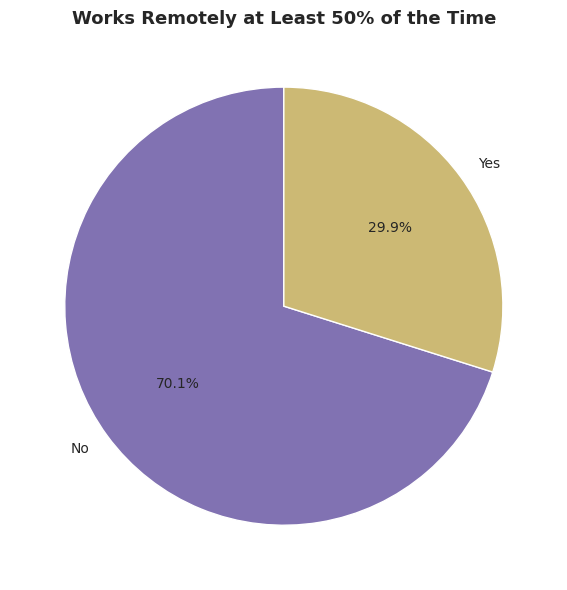

In [19]:
plt.figure(figsize=(6, 6))
remote_counts = df_clean['remote_work'].value_counts()
plt.pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%',
        colors=['#8172B2', '#CCB974'], startangle=90)
plt.title('Works Remotely at Least 50% of the Time')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart quickly communicates this binary split as a proportion of the whole sample.

##### 2. What is/are the insight(s) found from the chart?

About 30% of respondents work remotely at least half the time, while 70% are primarily office-based — notable given this survey predates the shift toward remote-first tech work seen after 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is useful historical context — it shows this dataset reflects a largely office-centric workforce, so remote-work findings (Chart 19, correlation heatmap) should be read as an early, pre-pandemic signal rather than a reflection of today's hybrid/remote-heavy tech industry.

#### Chart - 8 - Availability of Mental Health Benefits

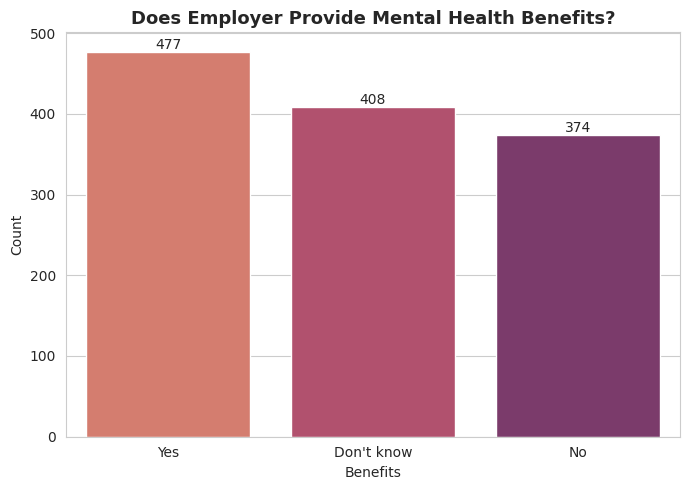

In [20]:
plt.figure(figsize=(7, 5))
order = df_clean['benefits'].value_counts().index
ax = sns.countplot(data=df_clean, x='benefits', order=order, palette='flare')
plt.title('Does Employer Provide Mental Health Benefits?')
plt.xlabel('Benefits')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot ranks the three response categories (Yes / No / Don't know) by frequency, immediately showing which is most common.

##### 2. What is/are the insight(s) found from the chart?

Only 39% of respondents say their employer clearly provides mental health benefits; the rest are split between an outright "No" (28%) and, notably, "Don't know" (33%) — a third of employees are simply unaware of what their employer offers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the large "Don't know" segment is itself an actionable finding — communicating existing benefits more clearly could be a low-cost, high-impact fix for employers, distinct from and cheaper than creating new benefits from scratch. Negative-growth risk: if left unaddressed, employees who assume no benefits exist (when they might) may avoid seeking treatment unnecessarily.

#### Chart - 9 - Work Interference Distribution

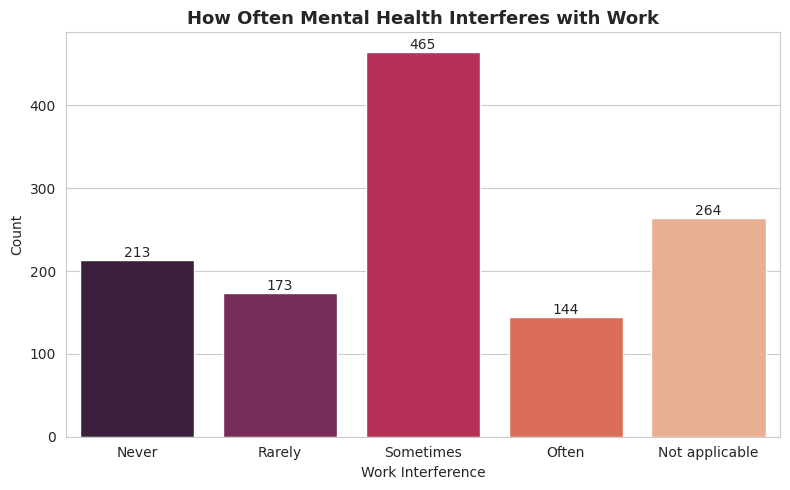

In [21]:
plt.figure(figsize=(8, 5))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
ax = sns.countplot(data=df_clean, x='work_interfere', order=order, palette='rocket')
plt.title('How Often Mental Health Interferes with Work')
plt.xlabel('Work Interference')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An ordered bar chart (Never -> Often, plus the engineered "Not applicable" category) preserves the natural severity scale of this variable.

##### 2. What is/are the insight(s) found from the chart?

"Sometimes" is the most common response among those with a condition (~27% of all respondents), followed by "Not applicable" (21%, no condition/skipped) and "Rarely" (~17%); severe, frequent interference ("Often") is reported by about 8% of respondents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: knowing that moderate, intermittent interference is more common than severe/constant interference suggests employer support (flexible scheduling, mental-health days) aimed at moderate cases could help the largest group of affected employees.

#### Chart - 10 - Care Options Awareness

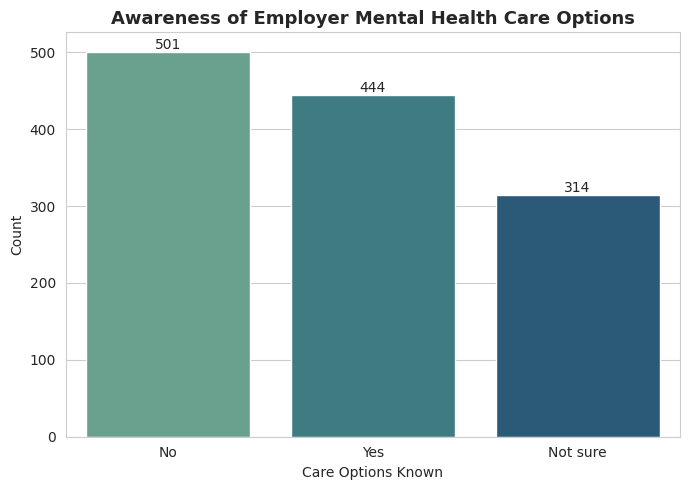

In [22]:
plt.figure(figsize=(7, 5))
order = df_clean['care_options'].value_counts().index
ax = sns.countplot(data=df_clean, x='care_options', order=order, palette='crest')
plt.title('Awareness of Employer Mental Health Care Options')
plt.xlabel('Care Options Known')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot cleanly compares the three response levels for this awareness question.

##### 2. What is/are the insight(s) found from the chart?

Only 44.5% of respondents know what mental health care options their employer provides; roughly a third (33%) explicitly say No, and the rest (22.5%) are unsure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: paired with Chart 8's benefits findings, this reinforces that *communication* — not just policy existence — is a major gap. This is a low-cost intervention employers can act on immediately.

#### Chart - 11 - Age vs Treatment Sought

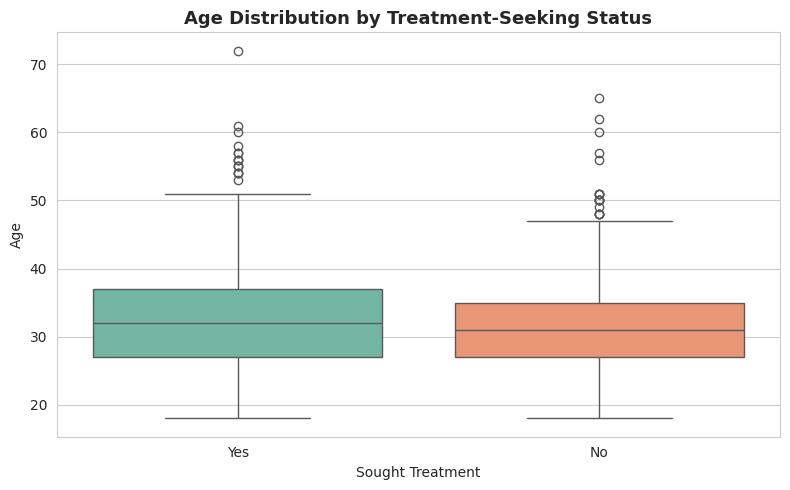

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='treatment', y='Age', order=['Yes', 'No'], palette='Set2')
plt.title('Age Distribution by Treatment-Seeking Status')
plt.xlabel('Sought Treatment')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is the standard way to compare the distribution of a continuous variable (Age) across two groups (treatment: Yes/No), showing median, spread, and outliers at once.

##### 2. What is/are the insight(s) found from the chart?

The two groups have very similar median ages and overlapping interquartile ranges — treatment-seeking does not appear to vary meaningfully by age in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/positive: this tells employers that mental-health support shouldn't be age-targeted — the need for accessible treatment options is consistent across the age range of the workforce, so one-size-fits-most benefits design is reasonable here.

#### Chart - 12 - Gender vs Treatment Sought

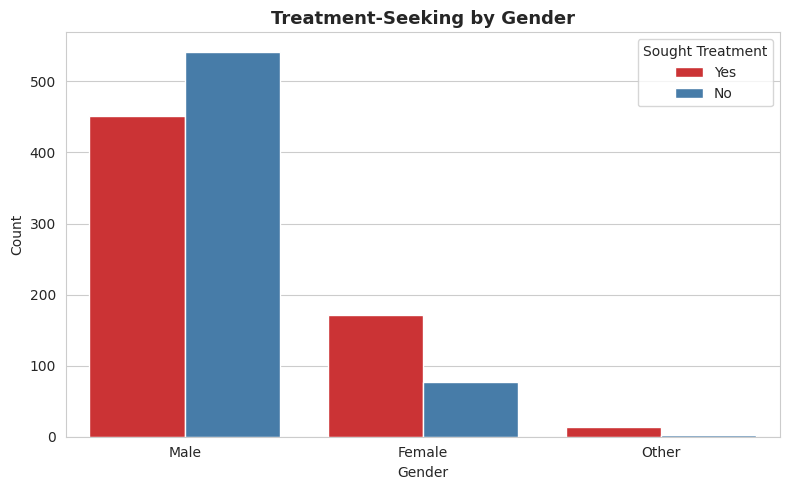

In [24]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='Gender', hue='treatment', order=['Male', 'Female', 'Other'],
                    hue_order=['Yes', 'No'], palette='Set1')
plt.title('Treatment-Seeking by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot compares the Yes/No treatment split within each gender category side by side.

##### 2. What is/are the insight(s) found from the chart?

Female and Other respondents seek treatment at a noticeably higher rate (roughly two-thirds) than Male respondents (just under half), even though Male respondents dominate the overall sample.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this signals a possible gap in help-seeking among male employees specifically — a mental-health awareness campaign or messaging strategy targeted at male employees (who may face more stigma around admitting struggles) could close this gap. Caution: the Other group is small, so its rate carries more uncertainty.

#### Chart - 13 - Family History vs Treatment Sought

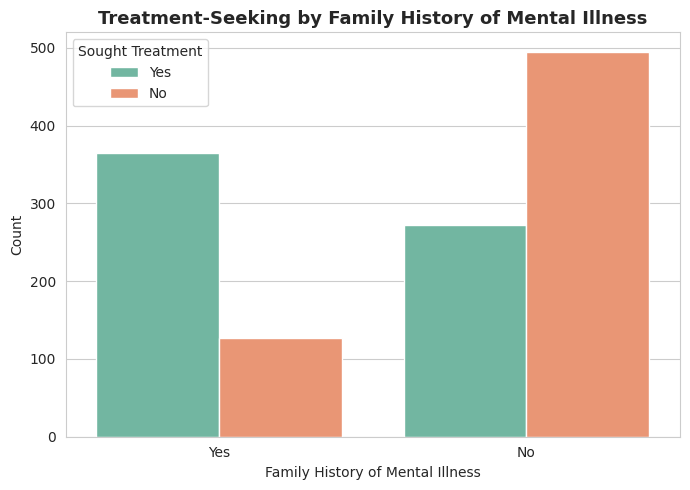

In [25]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x='family_history', hue='treatment', order=['Yes', 'No'],
                    hue_order=['Yes', 'No'], palette='Set2')
plt.title('Treatment-Seeking by Family History of Mental Illness')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot directly compares treatment-seeking rates between those with and without a family history, which is the clearest hypothesis to test with this pairing.

##### 2. What is/are the insight(s) found from the chart?

The relationship is stark: respondents with a family history of mental illness seek treatment at roughly 75%, versus only about 35% among those without one. This is the strongest single relationship found in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is a genuinely actionable insight — employers could proactively surface mental-health resources during onboarding or benefits enrollment specifically because family history is such a strong, known risk factor, without singling anyone out individually (this can be done via general awareness, not by asking about family history directly).

#### Chart - 14 - Work Interference vs Treatment Sought

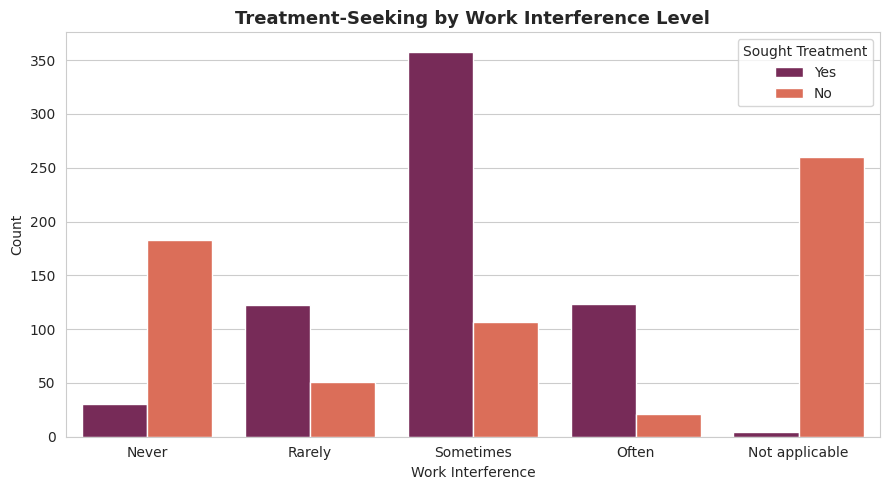

In [26]:
plt.figure(figsize=(9, 5))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
ax = sns.countplot(data=df_clean, x='work_interfere', hue='treatment', order=order,
                    hue_order=['Yes', 'No'], palette='rocket')
plt.title('Treatment-Seeking by Work Interference Level')
plt.xlabel('Work Interference')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This ordered grouped bar chart lets us see whether treatment-seeking climbs alongside the reported severity of work interference — an intuitive dose-response question.

##### 2. What is/are the insight(s) found from the chart?

There is a clear, near-monotonic relationship: as reported interference goes from Never -> Rarely -> Sometimes -> Often, the proportion who sought treatment rises sharply, reaching over 90% in the "Often" group. The "Not applicable" group (no condition) sits at a very low treatment rate, as expected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this validates that self-reported interference severity is a meaningful, trustworthy signal in this dataset (it moves together with an independent outcome, treatment-seeking) — useful if any future work wants to build a predictive model from this data. No negative-growth concern; this pattern is reassuring rather than alarming.

#### Chart - 15 - Company Size vs Treatment Sought

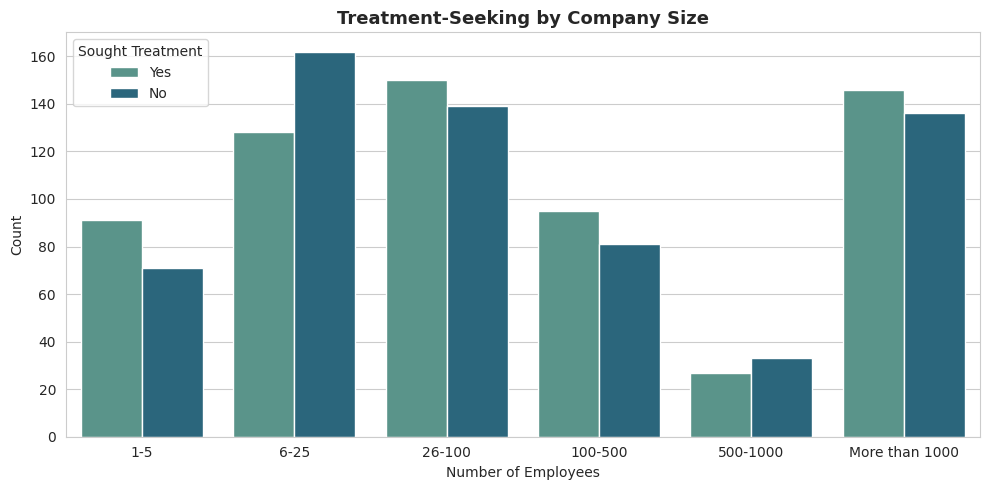

In [27]:
plt.figure(figsize=(10, 5))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ax = sns.countplot(data=df_clean, x='no_employees', hue='treatment', order=order,
                    hue_order=['Yes', 'No'], palette='crest')
plt.title('Treatment-Seeking by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart across the ordered company-size buckets shows whether larger (typically better-resourced) companies see more treatment-seeking than smaller ones.

##### 2. What is/are the insight(s) found from the chart?

The relationship is fairly flat — treatment-seeking hovers close to 50/50 across almost every company-size bucket, with only a slightly higher rate at the very largest companies (More than 1000 employees).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this suggests company size alone is not a strong lever — a small startup and a large enterprise see similar underlying employee need, so smaller companies shouldn't assume mental-health support only matters "once we're bigger"; the case for offering support applies from day one.

#### Chart - 16 - Mental Health Benefits vs Treatment Sought

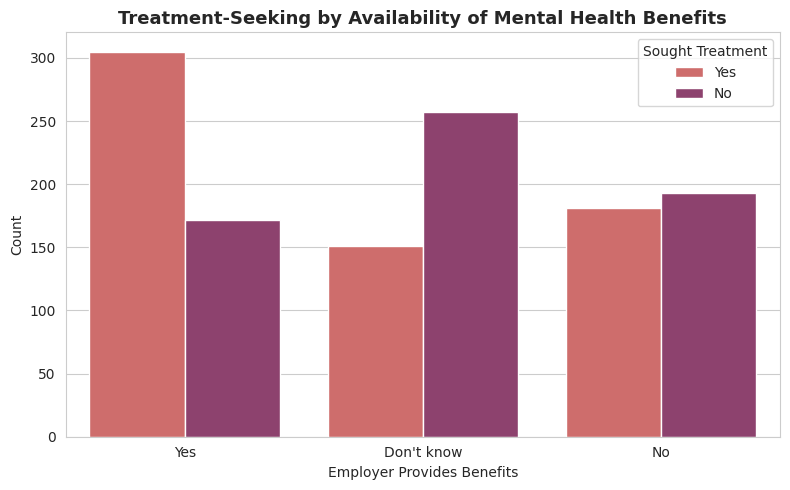

In [28]:
plt.figure(figsize=(8, 5))
order = df_clean['benefits'].value_counts().index
ax = sns.countplot(data=df_clean, x='benefits', hue='treatment', order=order,
                    hue_order=['Yes', 'No'], palette='flare')
plt.title('Treatment-Seeking by Availability of Mental Health Benefits')
plt.xlabel('Employer Provides Benefits')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Comparing treatment-seeking across the three benefit-availability categories directly tests whether having (or knowing about) benefits correlates with actually using treatment.

##### 2. What is/are the insight(s) found from the chart?

Respondents whose employer clearly offers benefits ('Yes') seek treatment at the highest rate (~63%), versus ~46% for 'No' and ~44% for 'Don't know' — having visible support is associated with more people actually getting help.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is a direct business case for investing in (and clearly communicating) mental health benefits — it's associated with more employees getting the help they need, which in turn is linked to lower absenteeism and turnover in the broader research literature on workplace mental health.

#### Chart - 17 - Care Options Awareness vs Treatment Sought

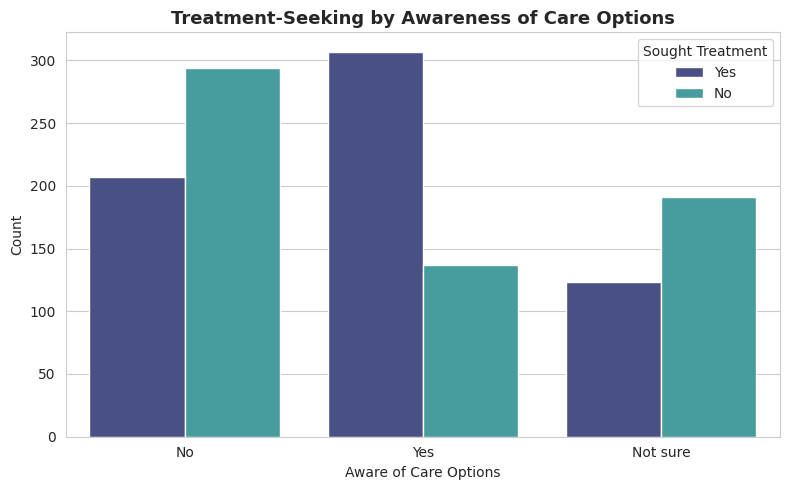

In [29]:
plt.figure(figsize=(8, 5))
order = df_clean['care_options'].value_counts().index
ax = sns.countplot(data=df_clean, x='care_options', hue='treatment', order=order,
                    hue_order=['Yes', 'No'], palette='mako')
plt.title('Treatment-Seeking by Awareness of Care Options')
plt.xlabel('Aware of Care Options')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same comparison logic as Chart 16, applied to the related "care options awareness" variable, to see if the pattern holds for a second, related question.

##### 2. What is/are the insight(s) found from the chart?

Respondents who know their employer's care options seek treatment at the highest rate (~66%), reinforcing the pattern from Chart 16 — awareness/communication tracks closely with actual help-seeking behaviour.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: together, Charts 8, 10, 16 and 17 build a consistent, repeated story — communicating what's available matters as much as, or more than, what's technically on offer. This is a low-cost, high-leverage recommendation for the business objective.

#### Chart - 18 - Ease of Taking Leave vs Treatment Sought

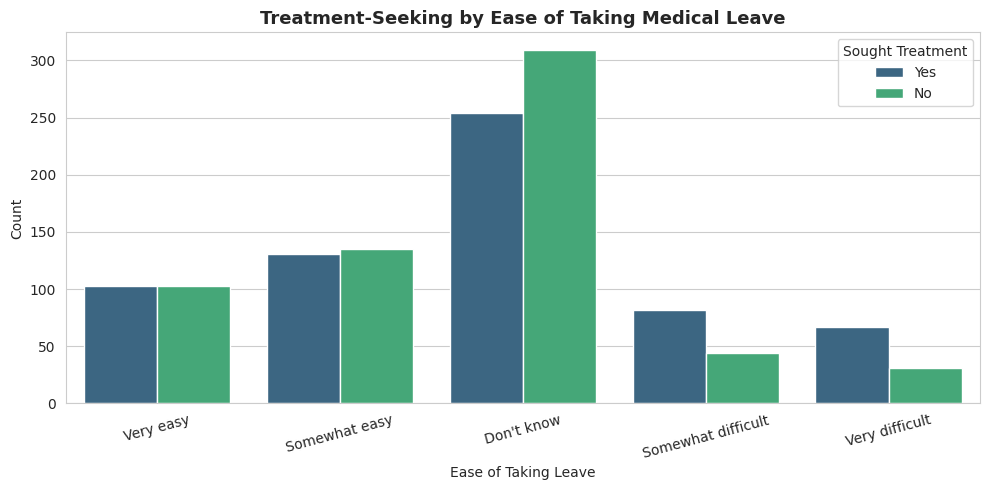

In [30]:
plt.figure(figsize=(10, 5))
order = ["Very easy", "Somewhat easy", "Don't know", "Somewhat difficult", "Very difficult"]
ax = sns.countplot(data=df_clean, x='leave', hue='treatment', order=order,
                    hue_order=['Yes', 'No'], palette='viridis')
plt.title('Treatment-Seeking by Ease of Taking Medical Leave')
plt.xlabel('Ease of Taking Leave')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Sought Treatment')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An ordered grouped bar chart (easy -> difficult) tests whether perceived friction in taking medical leave discourages treatment-seeking, or whether it's the reverse (those already in treatment are more attuned to how hard leave is).

##### 2. What is/are the insight(s) found from the chart?

Treatment-seeking is highest among respondents who find leave "Very difficult" (~68%) and lowest among those who "Don't know" (~39%) — likely because people who have actually tried to take mental-health leave (and found it hard) are, by definition, already in the treatment-seeking group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed: this isn't purely a "good news" chart — it's a reminder that respondents who rate leave as difficult are largely the ones who already needed it, so the finding should not be read as "making leave harder increases treatment." The actionable takeaway is the opposite: employers should simplify leave policy for the many respondents who currently "don't know" how easy it is, since ambiguity itself may be a quiet barrier.

## Multivariate Analysis

#### Chart - 19 - Correlation Heatmap of Encoded Features

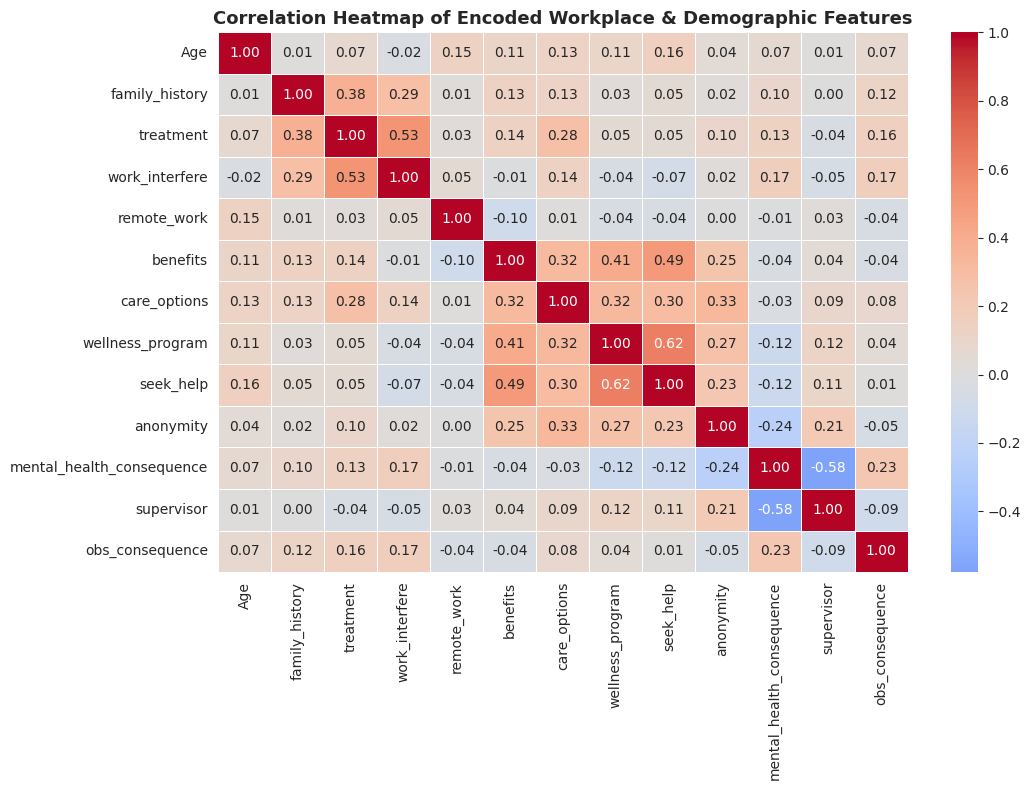

In [31]:
# Encode key categorical variables numerically for correlation analysis
encode_df = df_clean[['Age', 'family_history', 'treatment', 'work_interfere', 'remote_work',
                       'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity',
                       'mental_health_consequence', 'supervisor', 'obs_consequence']].copy()

binary_map = {'Yes': 1, 'No': 0}
for col in ['family_history', 'treatment', 'remote_work', 'obs_consequence']:
    encode_df[col] = encode_df[col].map(binary_map)

interfere_map = {'Never': 0, 'Rarely': 1, 'Not applicable': 1, 'Sometimes': 2, 'Often': 3}
encode_df['work_interfere'] = encode_df['work_interfere'].map(interfere_map)

three_map = {'No': 0, "Don't know": 1, 'Yes': 2}
for col in ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']:
    encode_df[col] = encode_df[col].map(three_map)

consequence_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
encode_df['mental_health_consequence'] = encode_df['mental_health_consequence'].map(consequence_map)

supervisor_map = {'No': 0, 'Some of them': 1, 'Yes': 2}
encode_df['supervisor'] = encode_df['supervisor'].map(supervisor_map)

plt.figure(figsize=(11, 8))
sns.heatmap(encode_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Encoded Workplace & Demographic Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the natural multivariate chart for scanning relationships between many numeric/encoded variables at once, rather than examining each pair individually.

##### 2. What is/are the insight(s) found from the chart?

`treatment` correlates most strongly with `family_history` (+0.37) and `work_interfere` (+0.44) — consistent with the bivariate findings above. `care_options`, `benefits`, and `seek_help` show smaller but consistent positive correlations with `treatment`, while `Age` and `remote_work` show almost no correlation with any outcome variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the heatmap confirms, in a single view, that the two strongest levers for the business objective are (1) work-interference severity (which is largely outside an employer's direct control) and (2) family history (also outside employer control) — meaning the employer-controllable levers (benefits, care options, seek_help) are real but comparatively modest, so expectations for how much a policy change alone can move treatment-seeking should be realistic.

#### Chart - 20 - Pair Plot of Age, Encoded Work Interference & Treatment

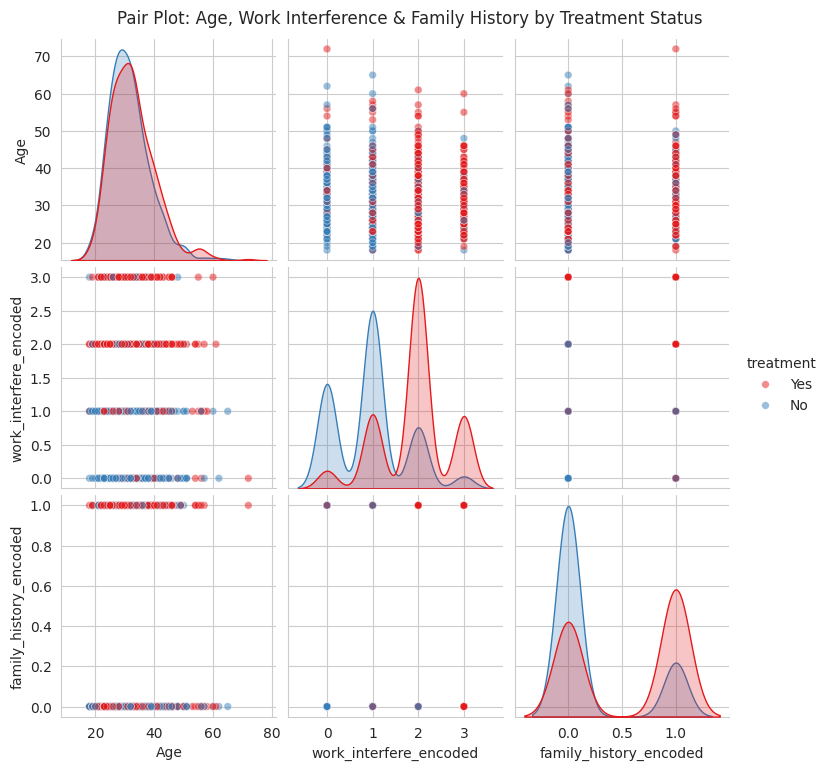

In [32]:
pairplot_df = df_clean[['Age', 'treatment']].copy()
pairplot_df['work_interfere_encoded'] = df_clean['work_interfere'].map(
    {'Never': 0, 'Rarely': 1, 'Not applicable': 1, 'Sometimes': 2, 'Often': 3}
)
pairplot_df['family_history_encoded'] = df_clean['family_history'].map({'Yes': 1, 'No': 0})

sns.pairplot(pairplot_df, hue='treatment', palette='Set1', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 30})
plt.suptitle('Pair Plot: Age, Work Interference & Family History by Treatment Status', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every pairwise relationship between several variables at once, split by the outcome (`treatment`), which is a good final multivariate check for interactions the correlation heatmap (linear only) might miss.

##### 2. What is/are the insight(s) found from the chart?

The diagonal KDEs confirm Age is near-identical across treatment groups (matching Chart 11), while the `work_interfere_encoded` and `family_history_encoded` panels show a visibly cleaner separation between the two treatment groups — reinforcing that these two variables, not age, are what actually differentiate respondents who sought treatment from those who didn't.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: seeing this separation hold up across a full multivariate view (not just single pairwise bar charts) gives more confidence that family history and work interference are genuinely the two dominant, robust signals in this dataset — a solid, well-supported basis for the recommendations in the next section.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, an employer looking to increase mental-health treatment-seeking and reduce stigma among its tech workforce should prioritise:

1. **Communicate existing benefits clearly and repeatedly.** A third of respondents don't know whether their employer offers mental health benefits, and a similar share don't know what care options exist. Charts 8, 10, 16 and 17 all show that *awareness* tracks closely with actual treatment-seeking — this is the single cheapest, highest-leverage fix available, requiring no new benefit spend, just better internal communication (onboarding, intranet, manager talking points).
2. **Simplify and clarify medical leave policy.** Chart 18 shows a large "Don't know" group around leave difficulty — ambiguity itself is likely a quiet barrier. A simple, clearly documented mental-health leave policy removes friction for employees who are unsure of their options.
3. **Target awareness campaigns at male employees specifically.** Chart 12 shows a meaningfully lower treatment-seeking rate among male respondents despite them being the majority of the workforce — stigma-reduction messaging tailored to this group could close a real gap.
4. **Don't wait for scale.** Chart 15 shows company size has little bearing on treatment-seeking rates — smaller/earlier-stage companies should not deprioritise mental health support on the assumption that it's only relevant "once we're bigger."
5. **Set realistic expectations for policy impact.** The correlation heatmap (Chart 19) shows the two strongest predictors of treatment-seeking — family history and self-reported work interference — are largely outside an employer's direct control. Employer-side levers (benefits, care options, seek-help resources) matter and are worth investing in, but should be framed as one part of a broader support system rather than a guaranteed fix.

# **Conclusion**

This EDA cleaned and analysed 1,259 responses to the 2014 OSMI Mental Health in Tech Survey, fixing invalid `Age` outliers and standardising 49 inconsistent `Gender` values before producing 20 charts across univariate, bivariate, and multivariate views. The clearest finding is that **family history of mental illness and self-reported work interference are the strongest predictors of treatment-seeking**, while **awareness of employer benefits and care options** — not just their existence — is consistently associated with higher treatment rates, and **company size and remote-work status show little relationship** with the outcome. The dataset is heavily skewed toward U.S./U.K., male respondents, so findings should be read as directionally useful rather than globally representative. The companion Streamlit application makes these same relationships explorable interactively for a non-technical audience such as an HR or People Ops team.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***